# Replicate Phenoscape Perturb-seq Plot

This notebook reproduces the early `2.0-pheonoscape.ipynb` style for Gupta perturb-seq. The workflow is:

1. Load all available phenoscape `distances.csv` runs.
2. Preview every run ID as a small PHATE plot.
3. Pick the visually best `RUN_ID`.
4. Render the final cluster-colored plot in the same style as the old notebook.

## Train/Test Perturbation Split for This Run

**Purpose:** mark generalization to unseen gene perturbations under the split6 protocol.

- **Unseen/test perturbation genes:** **CDKN1A, CSDE1, EGFL7, KMT2D, NME6, SLC2A6**
- **Training perturbation genes:** 39 non-control genes
- **Training reference perturbation to keep in plots:** **TP53**
- **Train/test non-control overlap:** none
- **Controls present in train/test:** `negative-control`

This split is generated by `runner/submit_UOT_meld_split6.sh` with `top_edist_only: true`, `rm_treat_wo_emb: true`, and `rm_from_train: true`. The six test genes are removed from the main model training set, so their validation metrics and plots should be labeled as **generalization to unseen perturbation genes**. **TP53 remains a training perturbation/reference gene and should be shown separately from the unseen genes.**

Training genes:

```text
B3GNT8, CCRL2, CDKN2B, CSNK2B-and-CSNK2B, Cmip-TSS2, DMXL1, DTYMK, EVL, FLI1, FYN, HINT3, HMGCR, IQGAP1, KLF4, MNT, MRPL3, MRPL34, MTPAP, NUFIP2, PAK2, POLG2, PRKAR1A-TSS2, RAB1A, REST, RPL7L1, SEC61A2, SHISA4, TAOK1, TP53, TRIP12, UGGT1, VPS45, WAC-TSS2, XPO7, YLPM1, ZNF281, ZNF827, ZNRF1, ZSWIM3
```


In [1]:
from pathlib import Path
import os
import sys
import re

import dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from omegaconf import OmegaConf
from phate import PHATE
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

ENV = dotenv.dotenv_values(PROJECT_ROOT / ".env")
DATA_DIR = Path(ENV.get("DATA_DIR", PROJECT_ROOT / "datasets"))
LOGS_DIR = Path(ENV.get("LOGS_DIR", PROJECT_ROOT)) / "logs"

sns.set_theme(style="white", context="notebook")
PROJECT_ROOT

FIGURE_OUT_DIR = PROJECT_ROOT / "figures" / "perturb_seq"
FIGURE_OUT_DIR.mkdir(parents=True, exist_ok=True)
PHENOSCAPE_COLOR_TABLE = FIGURE_OUT_DIR / "phenoscape_cluster_colors.csv"

plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

def save_figure(fig, name):
    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(name)).strip("_")
    out = FIGURE_OUT_DIR / safe_name
    fig.savefig(f"{out}.pdf", bbox_inches="tight")
    fig.savefig(f"{out}.svg", bbox_inches="tight")
    fig.savefig(f"{out}.png", dpi=600, bbox_inches="tight")
    print(f"Saved {safe_name} to {FIGURE_OUT_DIR}")


## Load All Phenoscape Runs

Set `MULTIRUN_DIR` to the phenoscape sweep you want to inspect. The table gives the run IDs and hyperparameters; the next cell plots every run ID.

In [2]:
MULTIRUN_DIR = PROJECT_ROOT / "logs" / "phenoscape" / "multiruns" / "2026-05-06_16-29-34"

# Optional recompute path. Leave False for visualization.
COMPUTE_DISTANCES = False
OUT_DIR = PROJECT_ROOT / "notebooks" / "phenoscape_replicate_perturbseq"
OUT_DIR.mkdir(parents=True, exist_ok=True)

phenoscape_cfg = OmegaConf.create({
    "fname": "gupta/subset_top_5000_hvg_batch_rm.h5ad",
    "min_cells": 32,
    "subsample": 15000,
    "seed": 42,
    "use_cache": True,
    "n_pca": 25,
    "knn": 10,
    "t": 20,
    "k": 30,
    "eps": 1e-2,
    "is_reg": True,
    "debug": False,
    "gupta": {
        "etest_genes": True,
        "sample_size_batch": None,
        "sample_size_treatment": None,
    },
})

if COMPUTE_DISTANCES:
    import rootutils
    rootutils.setup_root(PROJECT_ROOT / "runner" / "phenoscape.py", indicator=".project-root", pythonpath=True)
    from runner.phenoscape import compute_distance_matrix, prepare_data

    adata, labels = prepare_data(phenoscape_cfg, data_dir=str(DATA_DIR))
    distances = compute_distance_matrix(adata, labels, phenoscape_cfg, debug=phenoscape_cfg.debug)
    dist = pd.DataFrame(distances, index=labels.columns, columns=labels.columns)
    run_dir = OUT_DIR / "single_run"
    run_dir.mkdir(parents=True, exist_ok=True)
    dist.to_csv(run_dir / "distances.csv")
    OmegaConf.save(phenoscape_cfg, run_dir / "config.yaml")
    MULTIRUN_DIR = OUT_DIR

print(MULTIRUN_DIR)

/gpfs/radev/project/krishnaswamy_smita/kx44/project/geosink-te/logs/phenoscape/multiruns/2026-05-06_16-29-34


In [3]:
def get_runs_from_dir(multirun_dir):
    multirun_dir = Path(multirun_dir)
    return sorted(
        [p.parent for p in multirun_dir.glob("*/distances.csv")],
        key=lambda p: int(p.name) if p.name.isdigit() else p.name,
    )

def load_run(run_dir):
    run_dir = Path(run_dir)
    dist = pd.read_csv(run_dir / "distances.csv", index_col=0)
    cfg_path = run_dir / ".hydra" / "config.yaml"
    if not cfg_path.exists():
        cfg_path = run_dir / "config.yaml"
    cfg = OmegaConf.to_container(OmegaConf.load(cfg_path), resolve=False) if cfg_path.exists() else {}
    cfg["run_id"] = int(run_dir.name) if run_dir.name.isdigit() else run_dir.name
    cfg["run_dir"] = str(run_dir)
    return dist, cfg

def summarize_runs(multirun_dir):
    rows = []
    for run_dir in get_runs_from_dir(multirun_dir):
        _, cfg = load_run(run_dir)
        rows.append({
            "run_id": cfg.get("run_id"),
            "run_dir": cfg.get("run_dir"),
            "etest_genes": cfg.get("gupta", {}).get("etest_genes"),
            "knn": cfg.get("knn"),
            "t": cfg.get("t"),
            "k": cfg.get("k"),
            "eps": cfg.get("eps"),
            "is_reg": cfg.get("is_reg"),
            "subsample": cfg.get("subsample"),
        })
    return pd.DataFrame(rows)

run_table = summarize_runs(MULTIRUN_DIR)
display(run_table)

,run_id,run_dir,etest_genes,knn,t,k,eps,is_reg,subsample
0,0,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,10,20,30,0.01,True,15000
1,1,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,10,20,30,0.10,True,15000
2,2,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,10,30,30,0.01,True,15000
3,3,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,10,30,30,0.10,True,15000
4,4,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,10,50,30,0.01,True,15000
5,5,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,10,50,30,0.10,True,15000
6,6,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,20,20,30,0.01,True,15000
7,7,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,20,20,30,0.10,True,15000
8,8,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,20,30,30,0.01,True,15000
9,9,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,True,20,30,30,0.10,True,15000


## Preview Every Run ID

Look at this grid first, then set `RUN_ID` in the next section to the run with the best visual separation.

    SGD-MDS may not have converged: stress changed by -11.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -9.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -16.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -9.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.


    SGD-MDS may not have converged: stress changed by -18.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.


/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtoo

    SGD-MDS may not have converged: stress changed by -9.7% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -13.3% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -8.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -15.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -8.7% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -16.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtoo

...

    SGD-MDS may not have converged: stress changed by -6.9% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by 3.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -7.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.


/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtoo

    SGD-MDS may not have converged: stress changed by -5.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -6.6% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -1.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -7.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.


/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtoo

,run_id,run_dir,spread_score,etest_genes,knn,t,eps
0,0,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.004578,True,10,20,0.01
6,6,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000438,True,20,20,0.01
18,18,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000434,False,10,20,0.01
2,2,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000330,True,10,30,0.01
20,20,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000117,False,10,30,0.01
4,4,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000075,True,10,50,0.01
24,24,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000042,False,20,20,0.01
12,12,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000039,True,30,20,0.01
22,22,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000018,False,10,50,0.01
10,10,/gpfs/radev/project/krishnaswamy_smita/kx44/pr...,0.000017,True,20,50,0.01


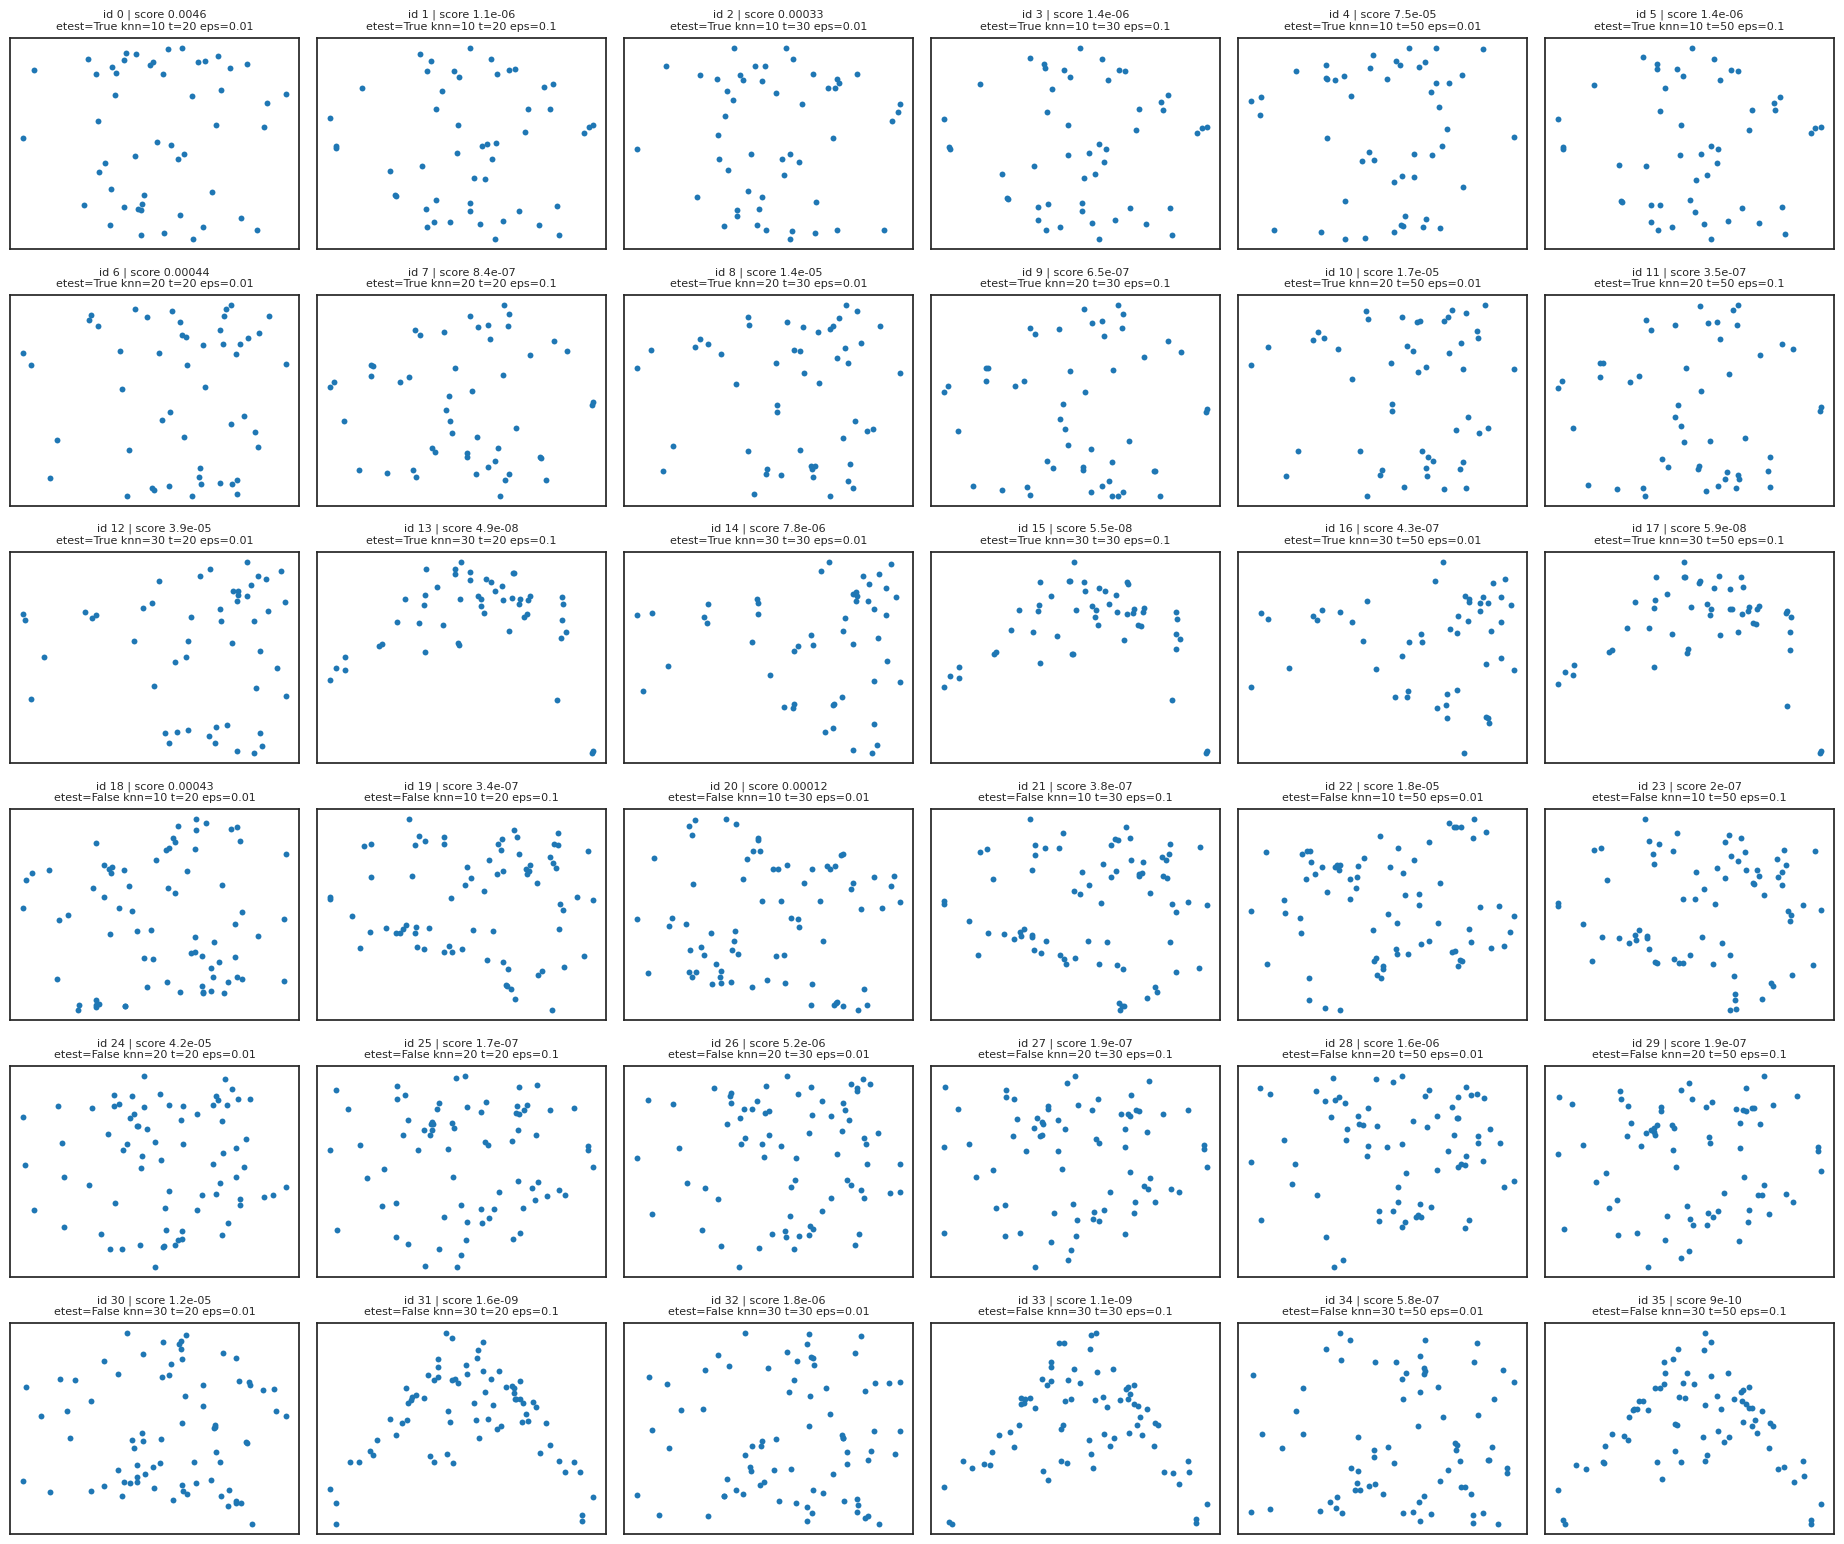

In [4]:
def embed_distance_matrix(dist, seed=1993, phate_knn=10, decay=10):
    dist = dist.copy()
    dist[dist < 0] = 0
    phate_op = PHATE(
        n_components=2,
        knn=phate_knn,
        verbose=False,
        decay=decay,
        knn_dist="precomputed_distance",
        random_state=seed,
    )
    x = phate_op.fit_transform(dist.values)
    return pd.DataFrame(x, index=dist.index, columns=["PHATE 1", "PHATE 2"])

def embedding_spread_score(emb):
    x = emb[["PHATE 1", "PHATE 2"]].to_numpy()
    x = x - x.mean(axis=0, keepdims=True)
    cov = np.cov(x.T)
    eig = np.clip(np.linalg.eigvalsh(cov), 1e-12, None)
    return float(np.sqrt(eig.prod()) * (eig.min() / eig.max()))

def preview_all_runs(run_table, seed=1993, phate_knn=10, decay=10, ncols=6):
    previews = []
    for _, row in run_table.iterrows():
        dist, _ = load_run(row["run_dir"])
        emb = embed_distance_matrix(dist, seed=seed, phate_knn=phate_knn, decay=decay)
        previews.append({
            "run_id": row["run_id"],
            "run_dir": row["run_dir"],
            "embedding": emb,
            "spread_score": embedding_spread_score(emb),
            "etest_genes": row.get("etest_genes"),
            "knn": row.get("knn"),
            "t": row.get("t"),
            "eps": row.get("eps"),
        })

    score_table = pd.DataFrame([
        {k: v for k, v in item.items() if k != "embedding"}
        for item in previews
    ]).sort_values("spread_score", ascending=False)

    n = len(previews)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.1 * ncols, 2.6 * nrows), squeeze=False)

    for ax, item in zip(axes.ravel(), previews):
        emb = item["embedding"]
        ax.scatter(emb["PHATE 1"], emb["PHATE 2"], s=18, linewidth=0, color="tab:blue")
        ax.set_title(
            f"id {item['run_id']} | score {item['spread_score']:.2g}\n"
            f"etest={item['etest_genes']} knn={item['knn']} t={item['t']} eps={item['eps']}",
            fontsize=8,
        )
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")

    for ax in axes.ravel()[len(previews):]:
        ax.axis("off")

    plt.tight_layout()
    return score_table, previews

score_table, previews = preview_all_runs(run_table, seed=1993, phate_knn=10, decay=10, ncols=6)
display(score_table.head(12))

## Final Figure For Selected Run

Change `RUN_ID` after looking at the preview grid. The final plot style mirrors the original notebook and the screenshot: scatter on the left, perturbation legend grouped by cluster on the right.

{'paths': {'root_dir': '${oc.env:PROJECT_ROOT}', 'data_dir': '${paths.root_dir}/data/', 'log_dir': '${oc.env:LOGS_DIR}/logs/', 'output_dir': '${hydra:runtime.output_dir}', 'work_dir': '${hydra:runtime.cwd}'}, 'fname': 'gupta/subset_top_5000_hvg_batch_rm.h5ad', 'subsample': 15000, 'debug': False, 'min_cells': 32, 'use_cache': True, 'n_pca': 25, 'knn': 30, 't': 20, 'k': 30, 'eps': 0.1, 'is_reg': True, 'gupta': {'etest_genes': False, 'sample_size_batch': None, 'sample_size_treatment': None}, 'original_work_dir': '${hydra:runtime.cwd}', 'seed': 42, 'name': 'phenoscape', 'task_name': '${name}', 'saving_cwd': None, 'run_id': 31, 'run_dir': '/gpfs/radev/project/krishnaswamy_smita/kx44/project/geosink-te/logs/phenoscape/multiruns/2026-05-06_16-29-34/31'}
    SGD-MDS may not have converged: stress changed by -5.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Unseen/test genes visible in this Phenoscape run: []
Training reference genes visible in this Phenoscape ru

/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: divide by zero encountered in divide
  pdx = (pdx.T / bandwidth).T
/gpfs/radev/home/kx44/.conda/envs/geosink-te/lib/python3.11/site-packages/graphtools/graphs.py:1593: RuntimeWarning: invalid value encountered in divide
  pdx = (pdx.T / bandwidth).T
/tmp/ipykernel_2015687/3658951621.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved phenoscape_perturbation_by_cluster to /gpfs/radev/project/krishnaswamy_smita/kx44/project/geosink-te/figures/perturb_seq


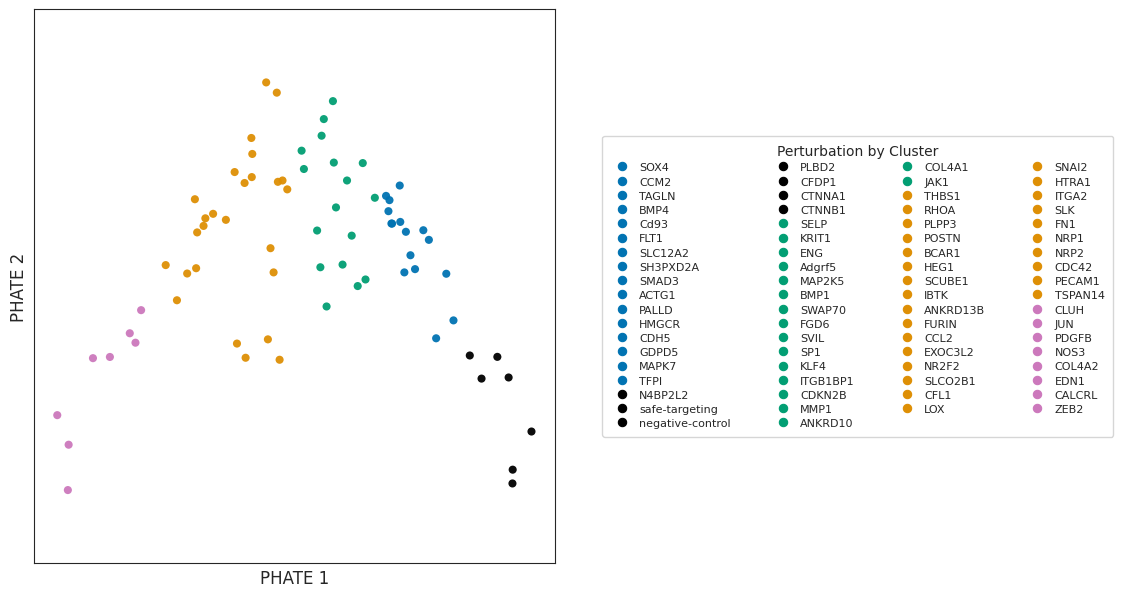

In [5]:
RUN_ID = 31
UNSEEN_TEST_GENES = {"CDKN1A", "CSDE1", "EGFL7", "KMT2D", "NME6", "SLC2A6"}
REFERENCE_TRAIN_GENES = {"TP53"}

selected_run_dir = Path(run_table.loc[run_table["run_id"] == RUN_ID, "run_dir"].iloc[0])
dist, config = load_run(selected_run_dir)
dist = dist.copy()
dist[dist < 0] = 0
print(config)

PHATE_SEED = 1993
PHATE_KNN = 10
PHATE_DECAY = 10
DENDRO_COLOR_THRESHOLD = 0.28

emb = embed_distance_matrix(dist, seed=PHATE_SEED, phate_knn=PHATE_KNN, decay=PHATE_DECAY)
X_transformed = emb[["PHATE 1", "PHATE 2"]].to_numpy()

pairwise_dist = np.sqrt(np.sum((X_transformed[:, None] - X_transformed[None]) ** 2, axis=-1))
linkage_matrix = linkage(squareform(pairwise_dist), method="ward")
cluster_ids = fcluster(linkage_matrix, t=DENDRO_COLOR_THRESHOLD, criterion="distance")

cluster_palette = [
    sns.color_palette("colorblind")[0],
    "black",
    sns.color_palette("colorblind")[2],
    sns.color_palette("colorblind")[1],
    sns.color_palette("colorblind")[4],
    sns.color_palette("colorblind")[3],
]
unique_clusters = list(dict.fromkeys(cluster_ids))
cluster_to_color = {cluster: cluster_palette[i % len(cluster_palette)] for i, cluster in enumerate(unique_clusters)}
emb["cluster"] = cluster_ids
emb["color"] = [cluster_to_color[c] for c in cluster_ids]
emb["split_role"] = "training/reference"
emb.loc[emb.index.astype(str).isin(UNSEEN_TEST_GENES), "split_role"] = "unseen_test"
emb.loc[emb.index.astype(str).isin(REFERENCE_TRAIN_GENES), "split_role"] = "reference_train"

ordered_genes = []
for cluster in unique_clusters:
    ordered_genes.extend(emb.index[emb["cluster"] == cluster].tolist())
gene_to_color = emb["color"].to_dict()
visible_unseen_test_genes = sorted(set(emb.index.astype(str)) & UNSEEN_TEST_GENES)
visible_reference_train_genes = sorted(set(emb.index.astype(str)) & REFERENCE_TRAIN_GENES)
print(f"Unseen/test genes visible in this Phenoscape run: {visible_unseen_test_genes}")
print(f"Training reference genes visible in this Phenoscape run: {visible_reference_train_genes}")

color_table = emb.reset_index(names="perturbed_gene")[["perturbed_gene", "cluster", "color", "split_role"]]
color_table.to_csv(PHENOSCAPE_COLOR_TABLE, index=False)
print(f"Saved phenoscape color table to {PHENOSCAPE_COLOR_TABLE}")

# Two-panel layout keeps the PHATE plot from being squeezed by a tall legend.
n_items = len(ordered_genes)
legend_ncol = 4 if n_items >= 56 else 3
legend_fontsize = 8 if n_items >= 56 else 9
legend_markersize = 6 if n_items >= 56 else 7
fig_height = max(4.8, min(7.2, 0.13 * n_items))

fig = plt.figure(figsize=(14.0, fig_height))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1], wspace=0.08)
ax = fig.add_subplot(gs[0, 0])
legend_ax = fig.add_subplot(gs[0, 1])
legend_ax.axis("off")

ax.scatter(
    emb["PHATE 1"],
    emb["PHATE 2"],
    c=emb["color"].tolist(),
    s=34,
    linewidth=0,
    alpha=0.95,
)

handles = [
    plt.Line2D(
        [0], [0], marker="o", linestyle="", color="w", label=gene,
        markerfacecolor=gene_to_color[gene],
        markeredgecolor=gene_to_color[gene],
        markeredgewidth=0.8,
        markersize=legend_markersize,
    )
    for gene in ordered_genes
]
legend_ax.legend(
    handles=handles,
    title="Perturbation by Cluster",
    ncol=legend_ncol,
    loc="center",
    bbox_to_anchor=(0, 0, 1, 1),
    mode="expand",
    frameon=True,
    fontsize=legend_fontsize,
    title_fontsize=10,
    handletextpad=0.55,
    columnspacing=1.15,
    borderpad=0.75,
    labelspacing=0.38,
)

ax.set_xlabel("PHATE 1", fontsize=12)
ax.set_ylabel("PHATE 2", fontsize=12)
ax.set_xticks([])
ax.set_yticks([])
ax.margins(x=0.05, y=0.18)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
plt.tight_layout()
save_figure(fig, "phenoscape_perturbation_by_cluster")
plt.show()


## Dendrogram Check

Use this to tune `DENDRO_COLOR_THRESHOLD` if the selected run's cluster split is too coarse or too fine.

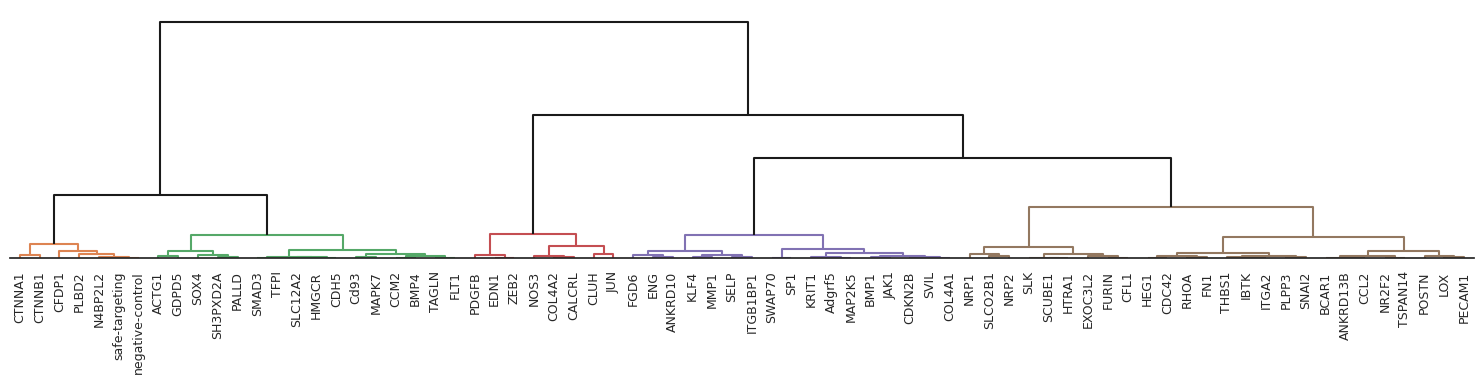

In [6]:
fig, ax = plt.subplots(figsize=(15, 4))
dendrogram(
    linkage_matrix,
    labels=dist.index,
    ax=ax,
    color_threshold=DENDRO_COLOR_THRESHOLD,
    above_threshold_color="k",
)
ax.set_yticks([])
ax.tick_params(axis="x", labelsize=9, rotation=90)
sns.despine(left=True)
plt.tight_layout()